In [2]:
import numpy as np
import matplotlib.pyplot as plt

############### We want to show the CLT graphically ###############
rng = np.random.default_rng(42)
num_experiments = 10000
p_heads = 0.5

# Sample means for different sample sizes
coin_tosses_100_avg = rng.binomial(1, p_heads, size=(num_experiments, 100)).mean(axis=1)
coin_tosses_1000_avg = rng.binomial(1, p_heads, size=(num_experiments, 1000)).mean(axis=1)
coin_tosses_10000_avg = rng.binomial(1, p_heads, size=(num_experiments, 10000)).mean(axis=1)


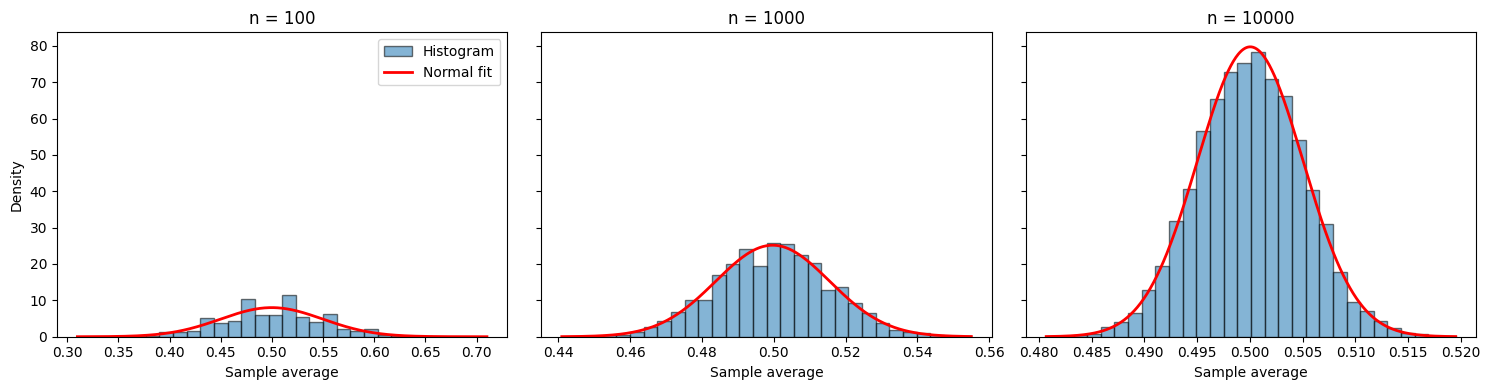

In [3]:
### plot the histograms of the averages to see the CLT in action ###
datasets = [
    (coin_tosses_100_avg, 100),
    (coin_tosses_1000_avg, 1000),
    (coin_tosses_10000_avg, 10000),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, (sample_means, n) in zip(axes, datasets):
    ax.hist(sample_means, bins=30, density=True, alpha=0.55, edgecolor='black', label='Histogram')
    x = np.linspace(sample_means.min(), sample_means.max(), 500)
    mu = np.mean(sample_means)
    sigma = np.std(sample_means, ddof=1)
    normal_pdf = (1.0 / (sigma * np.sqrt(2.0 * np.pi))) * np.exp(-0.5 * ((x - mu) / sigma) ** 2)
    ax.plot(x, normal_pdf, 'r-', linewidth=2.0, label='Normal fit')
    ax.set_title(f'n = {n}')
    ax.set_xlabel('Sample average')

axes[0].set_ylabel('Density')
axes[0].legend(loc='best')
plt.tight_layout()
plt.show()
